# 1. SPP-QLSTM
A Hybrid Quantum-Classical Model for Stock Price  rediction Using Quantum-Enhanced Long Short-Term Memory

https://www.mdpi.com/1099-4300/26/11/954

https://github.com/QCL-PKNU/SPP-QLSTM

## 1.1 Setup

In [ ]:
# @title
import torch
from torch import nn
from torch.utils.data import Dataset
import pennylane as qml

class SequenceDataset(Dataset):
    def __init__(self, dataframe, target, features, sequence_length=5):
        self.features = features
        self.target = target
        self.sequence_length = sequence_length
        self.y = torch.tensor(dataframe[self.target].values).float()
        self.X = torch.tensor(dataframe[self.features].values).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        if i >= self.sequence_length - 1:
            i_start = i - self.sequence_length + 1
            x = self.X[i_start : (i + 1), :]
        else:
            padding = self.X[0].repeat(self.sequence_length - i - 1, 1)
            x = self.X[0 : (i + 1), :]
            x = torch.cat((padding, x), 0)

        return x, self.y[i]


# Classical LSTM
class ShallowRegressionLSTM(nn.Module):
    def __init__(self, num_sensors, hidden_units, num_layers=1):
        super().__init__()
        self.num_sensors = num_sensors  # this is the number of features
        self.hidden_units = hidden_units
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=num_sensors,
            hidden_size=hidden_units,
            batch_first=True,
            num_layers=self.num_layers,
        )

        self.linear = nn.Linear(in_features=self.hidden_units, out_features=1)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(
            self.num_layers, batch_size, self.hidden_units
        ).requires_grad_()
        c0 = torch.zeros(
            self.num_layers, batch_size, self.hidden_units
        ).requires_grad_()

        _, (hn, _) = self.lstm(x, (h0, c0))
        out = self.linear(
            hn[0]
        ).flatten()  # First dim of Hn is num_layers, which is set to 1 above.

        return out


# Quantum LSTM
class QLSTM(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        n_qubits=4,
        n_qlayers=1,
        n_vrotations=3,
        batch_first=True,
        return_sequences=False,
        return_state=False,
        backend="default.qubit",
    ):
        super(QLSTM, self).__init__()
        self.n_inputs = input_size
        self.hidden_size = hidden_size
        self.concat_size = self.n_inputs + self.hidden_size
        self.n_qubits = n_qubits
        self.n_qlayers = n_qlayers
        self.n_vrotations = n_vrotations
        self.backend = backend  # "default.qubit", "qiskit.basicaer", "qiskit.ibm"

        self.batch_first = batch_first
        self.return_sequences = return_sequences
        self.return_state = return_state

        self.wires_forget = [f"wire_forget_{i}" for i in range(self.n_qubits)]
        self.wires_input = [f"wire_input_{i}" for i in range(self.n_qubits)]
        self.wires_update = [f"wire_update_{i}" for i in range(self.n_qubits)]
        self.wires_output = [f"wire_output_{i}" for i in range(self.n_qubits)]

        self.dev_forget = qml.device(self.backend, wires=self.wires_forget)
        self.dev_input = qml.device(self.backend, wires=self.wires_input)
        self.dev_update = qml.device(self.backend, wires=self.wires_update)
        self.dev_output = qml.device(self.backend, wires=self.wires_output)

        # self.dev_forget = qml.device(self.backend, wires=self.n_qubits)
        # self.dev_input = qml.device(self.backend, wires=self.n_qubits)
        # self.dev_update = qml.device(self.backend, wires=self.n_qubits)
        # self.dev_output = qml.device(self.backend, wires=self.n_qubits)

        def ansatz(params, wires_type):
            # Entangling layer.
            for i in range(1, 3):
                for j in range(self.n_qubits):
                    if j + i < self.n_qubits:
                        qml.CNOT(wires=[wires_type[j], wires_type[j + i]])
                    else:
                        qml.CNOT(
                            wires=[wires_type[j], wires_type[j + i - self.n_qubits]]
                        )

            # Variational layer.
            for i in range(self.n_qubits):
                qml.RX(params[0][i], wires=wires_type[i])
                qml.RY(params[1][i], wires=wires_type[i])
                qml.RZ(params[2][i], wires=wires_type[i])

        def VQC(features, weights, wires_type):
            # Preproccess input data to encode the initial state.
            qml.templates.AngleEmbedding(features, wires=wires_type)
            ry_params = [torch.arctan(feature) for feature in features][0]
            rz_params = [torch.arctan(feature**2) for feature in features][0]
            for i in range(self.n_qubits):
                qml.Hadamard(wires=wires_type[i])
                qml.RY(ry_params[i], wires=wires_type[i])
                qml.RZ(ry_params[i], wires=wires_type[i])

            # Variational block.
            qml.layer(ansatz, self.n_qlayers, weights, wires_type=wires_type)

        def _circuit_forget(inputs, weights):
            VQC(inputs, weights, self.wires_forget)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_forget]

        self.qlayer_forget = qml.QNode(
            _circuit_forget, self.dev_forget, interface="torch"
        )

        def _circuit_input(inputs, weights):
            VQC(inputs, weights, self.wires_input)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_input]

        self.qlayer_input = qml.QNode(_circuit_input, self.dev_input, interface="torch")

        def _circuit_update(inputs, weights):
            VQC(inputs, weights, self.wires_update)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_update]

        self.qlayer_update = qml.QNode(
            _circuit_update, self.dev_update, interface="torch"
        )

        def _circuit_output(inputs, weights):
            VQC(inputs, weights, self.wires_output)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_output]

        self.qlayer_output = qml.QNode(
            _circuit_output, self.dev_output, interface="torch"
        )

        weight_shapes = {"weights": (self.n_qlayers, self.n_vrotations, self.n_qubits)}
        print(
            f"weight_shapes = (n_qlayers, n_vrotations, n_qubits) = ({self.n_qlayers}, {self.n_vrotations}, {self.n_qubits})"
        )

        self.clayer_in = torch.nn.Linear(self.concat_size, self.n_qubits)
        self.VQC = {
            "forget": qml.qnn.TorchLayer(self.qlayer_forget, weight_shapes),
            "input": qml.qnn.TorchLayer(self.qlayer_input, weight_shapes),
            "update": qml.qnn.TorchLayer(self.qlayer_update, weight_shapes),
            "output": qml.qnn.TorchLayer(self.qlayer_output, weight_shapes),
        }
        self.clayer_out = torch.nn.Linear(self.n_qubits, self.hidden_size)
        # self.clayer_out = [torch.nn.Linear(n_qubits, self.hidden_size) for _ in range(4)]

    def forward(self, x, init_states=None):
        """
        x.shape is (batch_size, seq_length, feature_size)
        recurrent_activation -> sigmoid
        activation -> tanh
        """
        if self.batch_first is True:
            batch_size, seq_length, features_size = x.size()
        else:
            seq_length, batch_size, features_size = x.size()

        hidden_seq = []
        if init_states is None:
            h_t = torch.zeros(batch_size, self.hidden_size)  # hidden state (output)
            c_t = torch.zeros(batch_size, self.hidden_size)  # cell state
        else:
            # for now we ignore the fact that in PyTorch you can stack multiple RNNs
            # so we take only the first elements of the init_states tuple init_states[0][0], init_states[1][0]
            h_t, c_t = init_states
            h_t = h_t[0]
            c_t = c_t[0]

        for t in range(seq_length):
            # get features from the t-th element in seq, for all entries in the batch
            x_t = x[:, t, :]

            # Concatenate input and hidden state
            v_t = torch.cat((h_t, x_t), dim=1)

            # match qubit dimension
            y_t = self.clayer_in(v_t)

            f_t = torch.sigmoid(
                self.clayer_out(self.VQC["forget"](y_t))
            )  # forget block
            i_t = torch.sigmoid(self.clayer_out(self.VQC["input"](y_t)))  # input block
            g_t = torch.tanh(self.clayer_out(self.VQC["update"](y_t)))  # update block
            o_t = torch.sigmoid(
                self.clayer_out(self.VQC["output"](y_t))
            )  # output block

            c_t = (f_t * c_t) + (i_t * g_t)
            h_t = o_t * torch.tanh(c_t)

            hidden_seq.append(h_t.unsqueeze(0))
        hidden_seq = torch.cat(hidden_seq, dim=0)
        hidden_seq = hidden_seq.transpose(0, 1).contiguous()
        return hidden_seq, (h_t, c_t)


class QShallowRegressionLSTM(nn.Module):
    def __init__(self, num_sensors, hidden_units, n_qubits=0, n_qlayers=1):
        super().__init__()
        self.num_sensors = num_sensors  # this is the number of features
        self.hidden_units = hidden_units
        self.num_layers = 1

        self.lstm = QLSTM(
            input_size=num_sensors,
            hidden_size=hidden_units,
            batch_first=True,
            n_qubits=n_qubits,
            n_qlayers=n_qlayers,
        )

        self.linear = nn.Linear(in_features=self.hidden_units, out_features=1)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(
            self.num_layers, batch_size, self.hidden_units
        ).requires_grad_()
        c0 = torch.zeros(
            self.num_layers, batch_size, self.hidden_units
        ).requires_grad_()

        _, (hn, _) = self.lstm(x, (h0, c0))
        out = self.linear(
            hn
        ).flatten()  # First dim of Hn is num_layers, which is set to 1 above.

        return out

In [2]:
# @title
import pandas as pd

import time
import numpy as np
import math
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch import nn

from datetime import datetime

import yfinance as yf
from pandas_datareader import data as pdr

import scienceplots

# plt.style.use(['science','ieee'])
plt.rcParams['axes.grid'] = True
# no use latex
plt.rcParams['text.usetex'] = False

In [ ]:
# @title
df = pd.read_csv(DRIVE_FOLDER_PATH + '/SPP-QLSTM/AAPL_2022-01-01_2023-01-01.csv')
columns = ["Close"]

data = df.filter(columns)
dataset = data.values

In [ ]:
# @title
# Splitting the data into train and test
size = int(len(df) * 0.7)
df_train = dataset[:size].copy()
df_test = dataset[size:].copy()

In [ ]:
# @title
# Select the features
df_train = pd.DataFrame(df_train, columns=columns)
df_test = pd.DataFrame(df_test, columns=columns)

features = df_train.columns
target = 'Close'

In [ ]:
# @title
# Normalizing the data
def normalize(a, min_a=None, max_a=None):
    if min_a is None:
        min_a, max_a = np.min(a, axis=0), np.max(a, axis=0)
    return (a - min_a) / (max_a - min_a + 0.0001), min_a, max_a

df_train, min_train, max_train = normalize(df_train)
df_test, _, _ = normalize(df_test, min_train, max_train)

In [ ]:
# @title
torch.manual_seed(101)

batch_size = 1
sequence_length = 3

train_dataset = SequenceDataset(
    df_train,
    target=target,
    features=features,
    sequence_length=sequence_length
)
test_dataset = SequenceDataset(
    df_test,
    target=target,
    features=features,
    sequence_length=sequence_length
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X, y = next(iter(train_loader))

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: torch.Size([1, 3, 1])
Target shape: torch.Size([1])


In [ ]:
# @title
def train_model(data_loader, model, loss_function, optimizer):
    num_batches = len(data_loader)
    total_loss = 0
    model.train()

    for X, y in data_loader:
        output = model(X)
        loss = loss_function(output, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / num_batches
    print(f"Train loss: {avg_loss}")
    return avg_loss


def test_model(data_loader, model, loss_function):
    num_batches = len(data_loader)
    total_loss = 0

    model.eval()
    with torch.no_grad():
        for X, y in data_loader:
            output = model(X)
            total_loss += loss_function(output, y).item()

    avg_loss = total_loss / num_batches
    print(f"Test loss: {avg_loss}")
    return avg_loss

def predict(data_loader, model):
    """Just like `test_loop` function but keep track of the outputs instead of the loss
    function.
    """
    output = torch.tensor([])
    model.eval()
    with torch.no_grad():
        for X, _ in data_loader:
            y_star = model(X)
            output = torch.cat((output, y_star), 0)

    return output

## 1.2 QLSTM - Classical

In [ ]:
# @title
learning_rate = 0.01
num_hidden_units = 7

model_classic = ShallowRegressionLSTM(
    num_sensors=len(features),
    hidden_units=num_hidden_units,
    num_layers=1
)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model_classic.parameters(), lr=learning_rate)

In [ ]:
# @title
# Count number of parameters
num_params = sum(p.numel() for p in model_classic.parameters() if p.requires_grad)
print(f"Number of parameters: {num_params}")

Number of parameters: 288


In [ ]:
# @title
classical_loss_train = []
classical_loss_test = []
print("Untrained test\n--------")
# test_loss = test_model(test_loader, model_classic, loss_function)
print()

num_epochs = 50

for ix_epoch in range(num_epochs):
    print(f"Epoch {ix_epoch + 1}\n---------")
    train_loss = train_model(train_loader, model_classic, loss_function, optimizer=optimizer)
    test_loss = test_model(test_loader, model_classic, loss_function)
    classical_loss_train.append(train_loss)
    classical_loss_test.append(test_loss)

Untrained test
--------

Epoch 0
---------
Train loss: 0.02109941421084516
Test loss: 0.0050536135694361104
Epoch 1
---------
Train loss: 0.003029146214118855
Test loss: 0.002536470512154665
Epoch 2
---------
Train loss: 0.001810420824578744
Test loss: 0.0014311432991336772
Epoch 3
---------
Train loss: 0.0007256602219819439
Test loss: 0.00033755227300172477
Epoch 4
---------
Train loss: 0.00024456666755174694
Test loss: 0.00011370129018582388
Epoch 5
---------
Train loss: 4.596790222186493e-05
Test loss: 4.658174679491414e-05
Epoch 6
---------
Train loss: 2.1682944336132793e-05
Test loss: 2.74320234809304e-05
Epoch 7
---------
Train loss: 2.7012405384319037e-05
Test loss: 2.5473884052571916e-05
Epoch 8
---------
Train loss: 2.0050149307286244e-05
Test loss: 6.281355279805953e-05
Epoch 9
---------
Train loss: 3.664373115894546e-05
Test loss: 6.107104434679842e-05
Epoch 10
---------
Train loss: 2.518045634681292e-05
Test loss: 1.5572388864579673e-05
Epoch 11
---------
Train loss: 3.7374

In [ ]:
# @title
train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_eval_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ystar_col_Q = "Model Forecast"
df_train[ystar_col_Q] = predict(train_eval_loader, model_classic).numpy()
df_test[ystar_col_Q] = predict(test_eval_loader, model_classic).numpy()

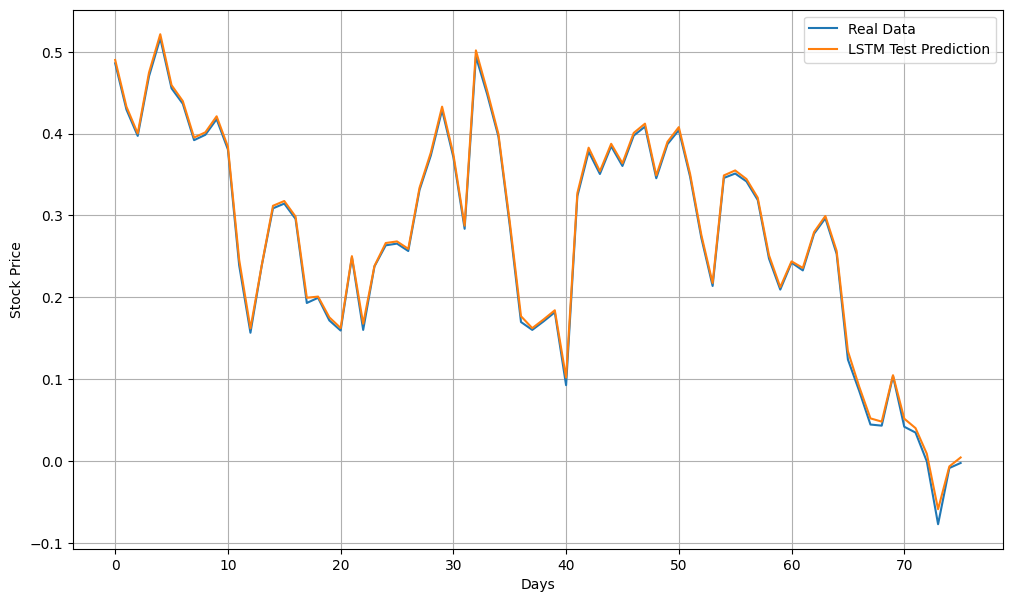

In [ ]:
# @title
plt.figure(figsize=(12, 7))
plt.plot(range(len(df_test)), df_test[columns], label = "Real Data")
plt.plot(range(len(df_test)), df_test["Model Forecast"], label = "LSTM Test Prediction")
plt.ylabel('Stock Price')
plt.xlabel('Days')
plt.legend()
plt.show()

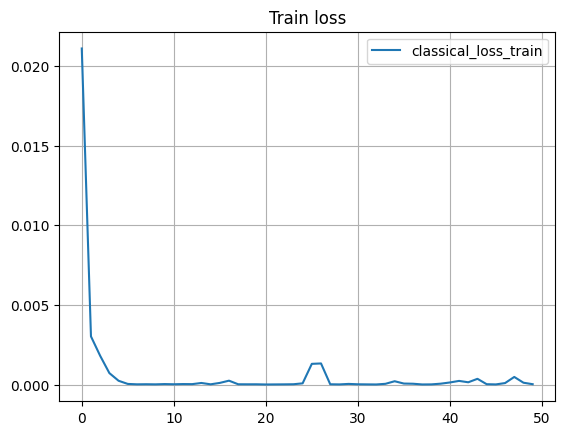

In [ ]:
plt.plot(classical_loss_train, label='classical_loss_train')
# plt.plot(classical_loss_test, label='classical_loss_test')
pd.DataFrame(classical_loss_train).to_csv('LSTM_loss.csv', index=False)
plt.title('Train loss')
plt.legend()

In [ ]:
# Calculate the RMSE for the train and test data
from sklearn.metrics import mean_squared_error

train_rmse = math.sqrt(mean_squared_error(df_train[columns], df_train["Model Forecast"]))
test_rmse = math.sqrt(mean_squared_error(df_test[columns], df_test["Model Forecast"]))
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

Train RMSE: 0.0045529790217386885
Test RMSE: 0.00486812711495303


In [ ]:
# Calculate the accuracy of the model
def accuracy(y, y_star):
    return np.mean(np.abs(y - y_star) < 0.1)

train_accuracy = accuracy(df_train["Close"], df_train["Model Forecast"])
test_accuracy = accuracy(df_test["Close"], df_test["Model Forecast"])
print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 1.0
Test accuracy: 1.0


## 1.3 QLSTM - Quantum

In [ ]:
df_train_quantum = df_train.copy()
df_test_quantum = df_test.copy()
min_train_quantum = min_train.copy()
max_train_quantum = max_train.copy()

print("Duplicated datasets and variables:")
print(f"- df_train_quantum: {df_train_quantum.shape}")
print(f"- df_test_quantum: {df_test_quantum.shape}")

Duplicated datasets and variables:
- df_train_quantum: (175, 1)
- df_test_quantum: (76, 1)


In [ ]:
train_dataset_quantum = SequenceDataset(
    df_train_quantum,
    target=target,
    features=features,
    sequence_length=sequence_length
)
test_dataset_quantum = SequenceDataset(
    df_test_quantum,
    target=target,
    features=features,
    sequence_length=sequence_length
)

# Also define specific loaders for the quantum training loop if needed
train_loader_quantum = DataLoader(train_dataset_quantum, batch_size=batch_size, shuffle=True)
test_loader_quantum = DataLoader(test_dataset_quantum, batch_size=batch_size, shuffle=False)

Quantum datasets and loaders created.


In [ ]:
learning_rate_quantum = 0.01
num_hidden_units_quantum = 16 # Reduced for resource management
num_qubit_quantum = 4 # Reduced for resource management

model_quantum = QShallowRegressionLSTM(
    num_sensors=len(features),
    hidden_units=num_hidden_units_quantum,
    n_qubits=num_qubit_quantum,
    n_qlayers=1
)
loss_function_quantum = nn.MSELoss()
optimizer_quantum = torch.optim.Adam(model_quantum.parameters(), lr=learning_rate_quantum)

weight_shapes = (n_qlayers, n_vrotations, n_qubits) = (1, 3, 4)


In [ ]:
# Count number of parameters
num_params_quantum = sum(p.numel() for p in model_quantum.parameters() if p.requires_grad)
print(f"Number of parameters: {num_params_quantum}")

Number of parameters: 169


In [ ]:
import os

quantum_loss_train = []
quantum_loss_test = []

# Ensure the save directory exists
checkpoint_dir = os.path.join(DRIVE_FOLDER_PATH, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, f'qlstm_model_quantum_latest_{num_hidden_units_quantum}unit_{num_qubit_quantum}qubit.pt')

num_epochs = 50
start_epoch = 0

# Load checkpoint if it exists to resume progress
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model_quantum.load_state_dict(checkpoint['model_state_dict'])
    optimizer_quantum.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")

if start_epoch >= num_epochs:
    print(f"Training already completed for {num_epochs} epochs.")
else:
    for ix_epoch in range(start_epoch, num_epochs):
        print(f"Epoch {ix_epoch + 1}/{num_epochs}\n---------")
        start = time.time()

        train_loss_quantum = train_model(train_loader_quantum, model_quantum, loss_function_quantum, optimizer=optimizer_quantum)
        test_loss_quantum = test_model(test_loader_quantum, model_quantum, loss_function_quantum)

        # Save weights after each epoch
        torch.save({
            'epoch': ix_epoch,
            'model_state_dict': model_quantum.state_dict(),
            'optimizer_state_dict': optimizer_quantum.state_dict(),
            'train_loss': train_loss_quantum,
            'test_loss': test_loss_quantum
        }, checkpoint_path)

        end = time.time()
        print(f"Epoch {ix_epoch + 1} saved to {checkpoint_path}")
        print("Execution time for this epoch:", end - start)

        quantum_loss_train.append(train_loss_quantum)
        quantum_loss_test.append(test_loss_quantum)

Resuming from epoch 29
Epoch 30/50
---------
Train loss: 0.0002773372651716142
Test loss: 0.0012489862533412502
Epoch 30 saved to /content/drive/MyDrive/School/HKU COMP7705 Capstone Project/checkpoints/qlstm_model_quantum_latest_16unit_4qubit.pt
Execution time for this epoch: 94.99709153175354
Epoch 31/50
---------
Train loss: 0.0002779226572088232
Test loss: 0.00023615744698240722
Epoch 31 saved to /content/drive/MyDrive/School/HKU COMP7705 Capstone Project/checkpoints/qlstm_model_quantum_latest_16unit_4qubit.pt
Execution time for this epoch: 86.58607029914856
Epoch 32/50
---------
Train loss: 0.0002881862780930484
Test loss: 0.0003802653165806939
Epoch 32 saved to /content/drive/MyDrive/School/HKU COMP7705 Capstone Project/checkpoints/qlstm_model_quantum_latest_16unit_4qubit.pt
Execution time for this epoch: 86.53110957145691
Epoch 33/50
---------
Train loss: 0.00011346852107889407
Test loss: 8.721428935923461e-05
Epoch 33 saved to /content/drive/MyDrive/School/HKU COMP7705 Capstone 

In [ ]:
train_eval_loader_quantum = DataLoader(train_dataset_quantum, batch_size=batch_size, shuffle=False)
test_eval_loader_quantum = DataLoader(test_dataset_quantum, batch_size=batch_size, shuffle=False)

ystar_col_Q = "Model Forecast"
df_train_quantum[ystar_col_Q] = predict(train_eval_loader_quantum, model_quantum).numpy()
df_test_quantum[ystar_col_Q] = predict(test_eval_loader_quantum, model_quantum).numpy()

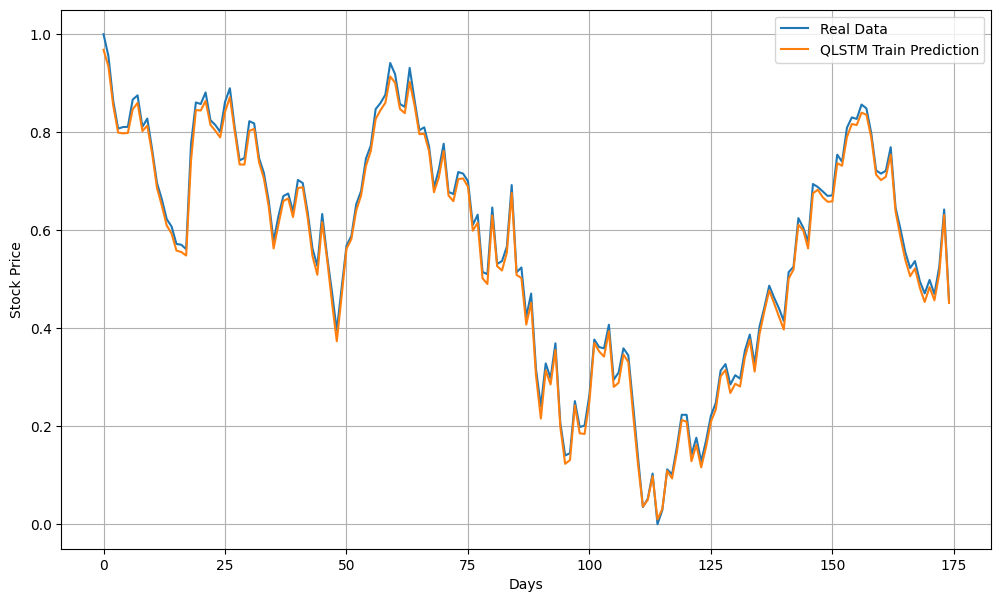

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(range(len(df_train_quantum)), df_train_quantum["Close"], label = "Real Data")
plt.plot(range(len(df_train_quantum)), df_train_quantum["Model Forecast"], label = "QLSTM Train Prediction")
plt.ylabel('Stock Price')
plt.xlabel('Days')
plt.legend()
plt.show()

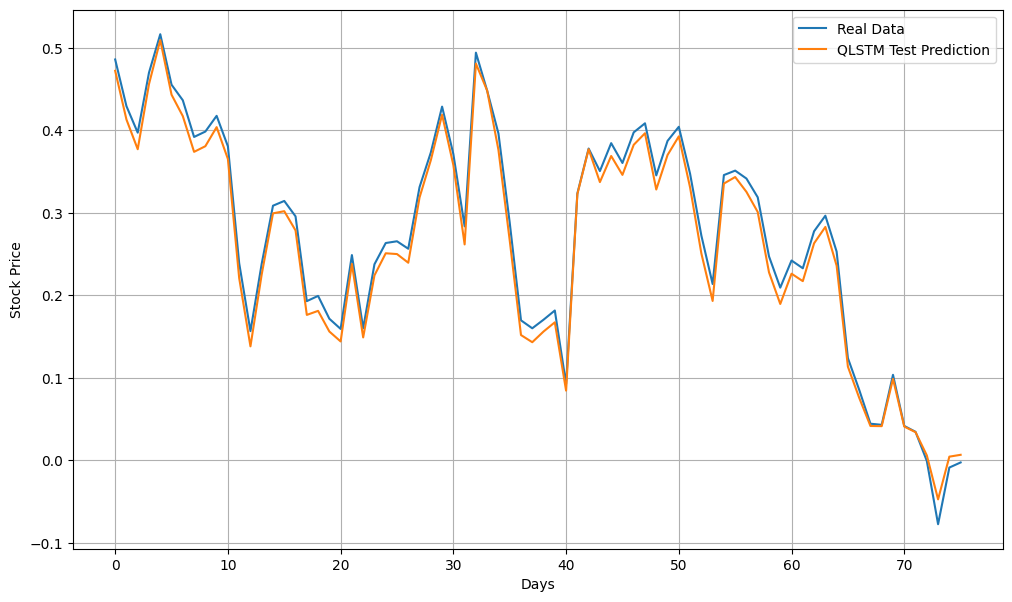

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(range(len(df_test_quantum)), df_test_quantum["Close"], label = "Real Data")
plt.plot(range(len(df_test_quantum)), df_test_quantum["Model Forecast"], label = "QLSTM Test Prediction")
plt.ylabel('Stock Price')
plt.xlabel('Days')
plt.legend()
plt.show()

In [ ]:
# Calculate the RMSE for the train and test data
from sklearn.metrics import mean_squared_error

train_rmse_quantum = math.sqrt(mean_squared_error(df_train_quantum["Close"], df_train_quantum["Model Forecast"]))
test_rmse_quantum = math.sqrt(mean_squared_error(df_test_quantum["Close"], df_test_quantum["Model Forecast"]))
print(f"Train RMSE: {train_rmse_quantum}")
print(f"Test RMSE: {test_rmse_quantum}")

Train RMSE: 0.014200009613869854
Test RMSE: 0.014677393957143032


In [ ]:
# Calculate the accuracy of the model
def accuracy(y, y_star):
    return np.mean(np.abs(y - y_star) < 0.03)

train_accuracy_quantum = accuracy(df_train_quantum["Close"], df_train_quantum["Model Forecast"])
test_accuracy_quantum = accuracy(df_test_quantum["Close"], df_test_quantum["Model Forecast"])
print(f"Train accuracy: {train_accuracy_quantum}")
print(f"Test accuracy: {test_accuracy_quantum}")

Train accuracy: 0.9885714285714285
Test accuracy: 0.9868421052631579


# 2. Hybrid-QNN-Finance

HQNN-FSP: A Hybrid Classical-Quantum Neural Network for Regression-Based Financial Stock Market Prediction

https://arxiv.org/abs/2503.15403

https://github.com/PrajwalNeupane/Hybrid-QNN-Finance (incomplete)

https://www.themoonlight.io/zh/review/quantitative-evaluation-of-quantumclassical-neural-network-using-a-game-solver-metric

In [ ]:
!pip install qiskit tensorflow qiskit_machine_learning pylatexenc

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import MinMaxScaler

def build_quantum_data_pipeline(df: pd.DataFrame, target_col: str = 'close', lookback: int = 2):
    """
    Implements the Data Preparation Pipeline from Figure 3.
    Requires a pandas DataFrame with 'open', 'high', 'low', 'close' columns.
    """
    data = df.copy()

    # 1. Calculate Technical Indicators (Simplified without external libraries)
    # RSI (14-day)
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    # MACD (12, 26, 9)
    ema_12 = data['close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = ema_12 - ema_26
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

    # SMA (5, 20)
    data['SMA5'] = data['close'].rolling(window=5).mean()
    data['SMA20'] = data['close'].rolling(window=20).mean()

    # Drop NaNs created by rolling windows
    data = data.dropna()

    # Define features (X) and target (y)
    X = data.drop(columns=[target_col])
    y = data[target_col]

    # 2. Feature Selection (SelectKBest k=5)
    selector = SelectKBest(score_func=f_regression, k=5)
    X_selected = selector.fit_transform(X, y)

    selected_feature_names = X.columns[selector.get_support()]
    print(f"Selected 5 Features: {list(selected_feature_names)}")

    # 3. Quantum Normalization to [-1, 1]
    quantum_scaler = MinMaxScaler(feature_range=(-1.0, 1.0))
    X_quantum_scaled = quantum_scaler.fit_transform(X_selected)

    # Note: Fig 3 states the classical target is scaled to [0, 1]
    classical_scaler = MinMaxScaler(feature_range=(0, 1))
    y_scaled = classical_scaler.fit_transform(y.values.reshape(-1, 1))

    return X_quantum_scaled, y_scaled, quantum_scaler, classical_scaler

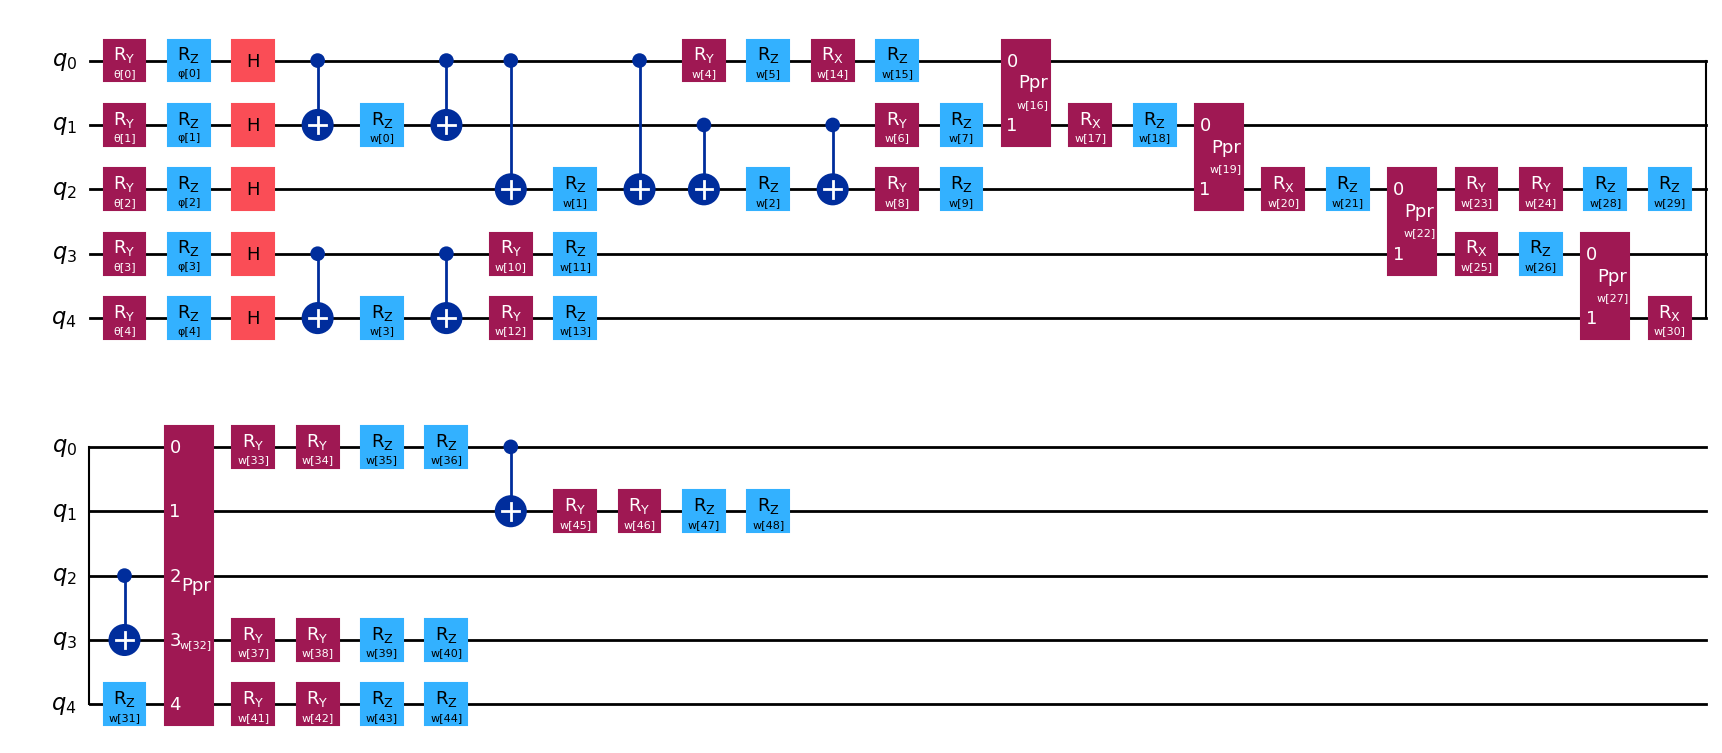

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Gate, ParameterVector
from qiskit.quantum_info import Statevector
from qiskit.primitives import Sampler

DEFAULT_NUM_QUBITS = 5

def compute_angle_encoding(
    features: Sequence[float],
    f_transform=None,
    g_transform=None,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute the Fig. 4 angles defined in the paper."""

    x = np.asarray(features, dtype=float)
    f_values = x if f_transform is None else np.asarray(f_transform(x), dtype=float)
    g_values = x if g_transform is None else np.asarray(g_transform(x), dtype=float)
    theta = np.arcsin(np.clip(f_values, -1.0, 1.0))
    phi = np.arccos(np.clip(g_values, -1.0, 1.0))
    return theta, phi


def build_angle_encoding_circuit(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Build the angle encoding circuit from Fig. 4."""
    theta = ParameterVector('θ', num_qubits)
    phi = ParameterVector('φ', num_qubits)

    circuit = QuantumCircuit(num_qubits, name="fig4_angle_encoding")
    for qubit in range(num_qubits):
        circuit.ry(theta[qubit], qubit)
        circuit.rz(phi[qubit], qubit)
    return circuit


def ppr_gate(width: int) -> Gate:
    """Return the custom `Ppr(0)` gate shown in the paper's circuit."""

    gate = Gate(name="Ppr", num_qubits=width, params=[0])
    # The paper does not define Ppr separately. Treat it as an opaque labeled identity block so the reproduced circuit can still be simulated.
    gate.definition = QuantumCircuit(width)
    return gate


def build_custom_qnn_ansatz_circuit(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Transcribe Fig. 5: customized QNN ansatz.

    Reference parts:
    - `arxiv_source/fig5.pdf` supplies the exact visible gate order.
    - The CNOT pairs come from the blue control/target vector geometry.
    - `Ppr(0)` is implemented as a labeled identity block because the paper
      does not separately define the Ppr unitary.
    """

    if num_qubits != DEFAULT_NUM_QUBITS:
        raise ValueError("Fig. 5 is a five-qubit circuit.")

    circuit = QuantumCircuit(num_qubits, name="fig5_custom_qnn_ansatz")

    weights = ParameterVector('w', 50)
    w_idx = 0

    circuit.h(range(num_qubits))
    circuit.cx(0, 1)
    circuit.rz(weights[w_idx], 1); w_idx += 1
    circuit.cx(0, 1)

    circuit.cx(0, 2)
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.cx(0, 2)

    circuit.cx(1, 2)
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.cx(1, 2)

    circuit.cx(3, 4)
    circuit.rz(weights[w_idx], 4); w_idx += 1
    circuit.cx(3, 4)

    circuit.ry(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1
    circuit.ry(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1
    circuit.ry(weights[w_idx], 2); w_idx += 1
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.ry(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1
    circuit.ry(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1

    circuit.rx(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [0, 1])

    circuit.rx(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [1, 2])

    circuit.rx(weights[w_idx], 2); w_idx += 1
    circuit.rz(weights[w_idx], 2); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [2, 3])

    circuit.ry(weights[w_idx], 2); w_idx += 1
    circuit.ry(weights[w_idx], 2); w_idx += 1
    circuit.rx(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1

    ppr_gate = Gate(name="Ppr", num_qubits=2, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [3, 4])

    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.rz(weights[w_idx], 2); w_idx += 1
    circuit.rx(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1
    circuit.cx(2, 3)

    ppr_gate = Gate(name="Ppr", num_qubits=5, params=[weights[w_idx]]); w_idx += 1
    circuit.append(ppr_gate, [0, 1, 2, 3, 4])

    circuit.ry(weights[w_idx], 0); w_idx += 1
    circuit.ry(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1
    circuit.rz(weights[w_idx], 0); w_idx += 1
    circuit.ry(weights[w_idx], 3); w_idx += 1
    circuit.ry(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1
    circuit.rz(weights[w_idx], 3); w_idx += 1
    circuit.ry(weights[w_idx], 4); w_idx += 1
    circuit.ry(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1
    circuit.rz(weights[w_idx], 4); w_idx += 1

    circuit.cx(0, 1)
    circuit.ry(weights[w_idx], 1); w_idx += 1
    circuit.ry(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1
    circuit.rz(weights[w_idx], 1); w_idx += 1

    return circuit


def build_angle_encoding_plus_ansatz(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Compose Fig. 4 angle encoding with the Fig. 5 QNN ansatz."""

    circuit = build_angle_encoding_circuit(num_qubits).compose(
        build_custom_qnn_ansatz_circuit(num_qubits)
    )
    circuit.name = "fig4_plus_fig5_custom_qnn_ansatz"
    return circuit

circuit = build_angle_encoding_plus_ansatz()
circuit.draw(output="mpl")


In [ ]:
def measure_and_execute_qnn(circuit: QuantumCircuit, feature_values: list, weight_values: list):
    """
    Applies measurements to the circuit and extracts the probability distributions.
    """
    # 1. Add measurements to all qubits
    meas_circuit = circuit.copy()
    meas_circuit.measure_all()

    # 2. Combine the data features (angles) and trainable weights into one list
    # Ensure this matches the exact order of parameters in your circuit!
    bound_parameters = feature_values + weight_values

    # 3. Execute using the Sampler primitive to get probability distributions
    sampler = Sampler()
    job = sampler.run(meas_circuit, parameter_values=[bound_parameters])
    result = job.result()

    # 4. Extract probabilities for Equation 7
    quasi_dists = result.quasi_dists[0]

    # In a regression task, you typically map these probabilities to a continuous value.
    # For example, taking the expectation value of the Z observable on the first qubit:
    # Expectation = P(|0>) - P(|1>)

    prob_0 = sum(prob for state, prob in quasi_dists.items() if (state & 1) == 0)
    prob_1 = sum(prob for state, prob in quasi_dists.items() if (state & 1) == 1)

    expectation_value = prob_0 - prob_1

    return expectation_value

In [ ]:

def build_qnn_regressor_circuit(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Transcribe Fig. 6: QNN Regressor circuit used in HybridQNN1.

    Reference parts:
    - The CNOT pairs come from the blue control/target vector geometry
    - The five `Ppr(0)` blocks are implemented as opaque Qiskit gates so the
      circuit remains runnable.
    """

    if num_qubits != DEFAULT_NUM_QUBITS:
        raise ValueError("Fig. 6 is a five-qubit circuit.")

    circuit = QuantumCircuit(num_qubits, name="fig6_qnn_regressor")

    # First line of the folded Qiskit drawing.
    circuit.h([0, 1, 2, 3, 4])
    circuit.cx(1, 2)
    circuit.cx(0, 4)
    circuit.rz(0, 2)
    circuit.rz(0, 4)
    circuit.cx(1, 2)
    circuit.cx(0, 4)
    circuit.ry(0, 0)
    circuit.ry(0, 4)
    circuit.cx(1, 3)
    circuit.rz(0, 0)
    circuit.rz(0, 3)
    circuit.rz(0, 4)
    circuit.rx(0, 0)
    circuit.cx(1, 3)
    circuit.rz(0, 0)
    circuit.ry(0, 1)
    circuit.cx(2, 3)
    circuit.rz(0, 1)
    circuit.rz(0, 3)
    circuit.append(ppr_gate(2), [0, 1])
    circuit.cx(2, 3)
    circuit.rx(0, 1)
    circuit.ry(0, 2)
    circuit.ry(0, 3)
    circuit.rz(0, 1)
    circuit.rz(0, 2)
    circuit.rz(0, 3)
    circuit.append(ppr_gate(2), [1, 2])
    circuit.rx(0, 2)
    circuit.rz(0, 2)
    circuit.append(ppr_gate(2), [2, 3])
    circuit.ry(0, 2)
    circuit.ry(0, 2)
    circuit.rx(0, 3)
    circuit.rz(0, 3)
    circuit.append(ppr_gate(2), [3, 4])
    circuit.rz(0, 2)
    circuit.rz(0, 2)
    circuit.rx(0, 4)
    circuit.rz(0, 4)
    circuit.cx(2, 3)
    circuit.append(ppr_gate(5), [0, 1, 2, 3, 4])
    circuit.ry(0, 0)
    circuit.ry(0, 3)
    circuit.ry(0, 4)

    # Continuation line
    circuit.ry(0, 0)
    circuit.rz(0, 0)
    circuit.rz(0, 0)
    circuit.cx(0, 1)
    circuit.ry(0, 1)
    circuit.ry(0, 1)
    circuit.rz(0, 1)
    circuit.rz(0, 1)
    circuit.ry(0, 3)
    circuit.rz(0, 3)
    circuit.rz(0, 3)
    circuit.ry(0, 4)
    circuit.rz(0, 4)
    circuit.rz(0, 4)

    return circuit


def build_full_qnn_pipeline(num_qubits: int = DEFAULT_NUM_QUBITS) -> QuantumCircuit:
    """Compose Fig. 4 angle encoding with the Fig. 6 QNN regressor."""

    circuit = build_angle_encoding_circuit(num_qubits).compose(
        build_qnn_regressor_circuit(num_qubits)
    )
    circuit.name = "fig4_plus_fig6_qnn_regressor"
    return circuit
